Launching server at http://localhost:65381


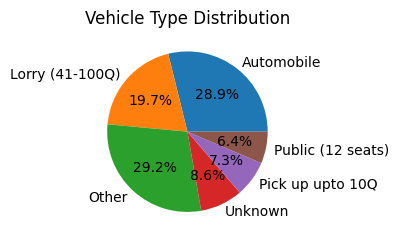

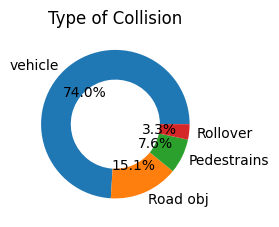

In [2]:
import pandas as pd
import hvplot.pandas
import panel as pn
import matplotlib.pyplot as plt

pn.extension('tabulator')

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("RTA_Cleaned_Dataset.csv")
df.columns = df.columns.str.strip()

df['Age_band_of_driver'] = df['Age_band_of_driver'].str.extract(r'(\d+)').astype(float)

# -----------------------------
# SIZE SETTINGS (BALANCED)
# -----------------------------
W = 400
H = 280
CARD_WIDTH = 420
CARD_HEIGHT = 360

# -----------------------------
# 1. HEATMAP
# -----------------------------
corr = df[['Number_of_vehicles_involved',
           'Number_of_casualties',
           'Age_band_of_driver']].corr()

heatmap = corr.hvplot.heatmap(cmap='Blues')

heatmap_card = pn.Card(heatmap, title="Correlation Heatmap",height=400,width = 740,margin = 10)

# -----------------------------
# 2. VEHICLE PIE (TOP 6 + OTHER)
# -----------------------------
vc = df['Type_of_vehicle'].value_counts()
top6 = vc.head(6)
others = vc.iloc[6:].sum()

vehicle_counts = top6.copy()
if others > 0:
    vehicle_counts['Other'] = others

fig1, ax1 = plt.subplots(figsize=(3.5, 2.8))
ax1.pie(vehicle_counts.values,
        labels=vehicle_counts.index,
        autopct='%1.1f%%')
ax1.set_title("Vehicle Type Distribution")
plt.tight_layout()

vehicle_card = pn.Card(
    pn.Column(pn.pane.Matplotlib(fig1, tight=True), align='center'),
    title="Vehicle Type Distribution",
    width = 710,
    margin = 10
    
)

# -----------------------------
# 3. CAUSE BAR
# -----------------------------
cause_counts = df['Cause_of_accident'].value_counts().head(6)

cause_bar = cause_counts.hvplot.barh()

cause_card = pn.Card(cause_bar, title="Cause of Accident (Top 6)", width=740, height=400,margin = 10)

# -----------------------------
# 4. COLLISION DONUT
# -----------------------------
cc = df['Type_of_collision'].value_counts().head(4)
top6c = cc.head(6)
others_c = cc.iloc[6:].sum()

collision_counts = top6c.copy()
if others_c > 0:
    collision_counts['Other'] = others_c

fig2, ax2 = plt.subplots(figsize = (2.8,4))
ax2.pie(collision_counts.values,
        labels=['vehicle', 'Road obj','Pedestrains','Rollover'],
        autopct='%1.1f%%',
        wedgeprops=dict(width=0.4))
ax2.set_title("Type of Collision")
plt.tight_layout()

collision_card = pn.Card(
    pn.Column(pn.pane.Matplotlib(fig2, tight=True), align='center'),
    title="Type of Collision",
    width=710,
    height=400
)

# -----------------------------
# 5. SEVERITY BAR
# -----------------------------
severity_counts = df['Accident_severity'].value_counts()

severity_bar = severity_counts.hvplot.bar(color= ["#4C78A8"])

severity_card = pn.Card(severity_bar,
                        title="Accident Severity Distribution",
                        width=710,
                        height=400,margin=10)

# -----------------------------
# 6. RADIO + LINE
# -----------------------------
radio = pn.widgets.RadioButtonGroup(
    name='Metric',
    options=['Accidents', 'Casualties', 'Vehicles'],
    button_type='primary'
)

def line_chart(metric):
    if metric == "Accidents":
        data = df['Day_of_week'].value_counts()
    elif metric == "Casualties":
        data = df.groupby('Day_of_week')['Number_of_casualties'].sum()
    else:
        data = df.groupby('Day_of_week')['Number_of_vehicles_involved'].sum()

    return data.hvplot.line(marker='o')

line_plot = pn.bind(line_chart, radio)

line_card = pn.Card(
    pn.Column(radio, line_plot),
    title="Accidents by Day of Week",
    width=740,
    height=400,margin=10
)

# -----------------------------
# TABLE
# -----------------------------
table = pn.widgets.Tabulator(
    df[['Day_of_week', 'Accident_severity', 'Age_band_of_driver',
        'Cause_of_accident', 'Number_of_vehicles_involved',
        'Number_of_casualties']].head(50),
    pagination='remote',
    page_size=8
)

table_card = pn.Card(table, title="Accident Records")

# -----------------------------
# PERFECT GRID LAYOUT
# -----------------------------
overview = pn.Column(
    pn.Row(heatmap_card, vehicle_card, sizing_mode="stretch_width"),
    pn.Row(cause_card, collision_card, sizing_mode="stretch_width"),
    pn.Row(severity_card, line_card, sizing_mode="stretch_width", margin=10),
    pn.Row('''# markdown
    ### This dashboard enables:
Identification of high-risk factors \n
Understanding accident trends \n
Data-driven decision making for road safety improvements''',table_card)
)

tabs = pn.Tabs(
    ("Overview", overview),
    ("Severity", severity_card)
)

dashboard = pn.Column(
    "# RTA Analytics Dashboard",
    tabs
)

dashboard.show()